# The AU-AIR dataset

- Preprocessing AU-AIR and extracting metadata into a csv file.

- Perform EDA.

## Mounting Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Then change directory to your drive before downloading
%cd /content/drive/MyDrive/

MessageError: Error: credential propagation was unsuccessful

## Downloading the dataset

In [ ]:
# Install gdown if it's not already updated
!pip install --upgrade gdown

# Download AU-AIR Images (zip file)
!gdown 1pJ3xfKtHiTdysX5G3dxqKTdGESOBYCxJ

# Download AU-AIR Annotations (json file)
!gdown 1boGF0L6olGe_Nu7rd1R8N7YmQErCb0xA

  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2
Downloading...
From (original): https://drive.google.com/uc?id=1pJ3xfKtHiTdysX5G3dxqKTdGESOBYCxJ
From (redirected): https://drive.google.com/uc?id=1pJ3xfKtHiTdysX5G3dxqKTdGESOBYCxJ&confirm=t&uuid=9984f5f3-bd95-4d04-ad49-f2f5a34e1323
To: /content/drive/MyDrive/auair2019data.zip
100% 2.32G/2.32G [00:45<00:00, 50.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1boGF0L6olGe_Nu7rd1R8N7YmQErCb0xA
To: /content/drive/MyDrive/auair2019annotations.zip
100% 4.04M/4.04M [00:00<00:00, 126MB/s]


In [ ]:
# Unzip the images
!unzip -q /content/drive/MyDrive/auair2019data.zip -d au_air_data/

# Check the contents
!ls au_air_data/

images


In [ ]:
!unzip -q /content/drive/MyDrive/auair2019annotations.zip -d au_air_labels/

!ls au_air_labels/

annotations.json


In [ ]:
import pandas as pd


## Setup of AU-AIR

In [ ]:
%cd au-air_dataset
!python setup.py install


/content/drive/MyDrive/au-air_dataset
running install
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` and ``easy_install``.
        Instead, use pypa/build, pypa/installer or other
        sta

## Process the json annotation file.

In [4]:
import sys
%cd /content/drive/MyDrive/

IMAGES = "au_air_data/images"
LABELS = "au_air_labels/annotations.json"

# Add the directory where auairtools resides to the Python path
sys.path.append('/content/drive/MyDrive/au-air_dataset')

import json
import os
import pandas as pd
from auairtools.auair import AUAIR
from auairtools.utils import TimeStamp

/content/drive/MyDrive


In [5]:
print("Loading AU-AIR dataset...")
auair = AUAIR(annotation_file=LABELS, data_folder=IMAGES)

print(f"Loaded {len(auair.annotations)} frames.")

Loading AU-AIR dataset...
Loading annotations into memory...
Done (t=1.38s)
32823 annotated frames are found.
Checking images...
32823 image files found.
Loaded 32823 frames.


In [6]:
# Sort annotations by timestamp
print("Sorting frames by timestamp...")
sorted_annotations = auair._sort_by_time(auair.annotations)

Sorting frames by timestamp...


In [ ]:
# type(sorted_annotations)
# print(sorted_annotations[0]['image_name'])
# print(sorted_annotations[0]['image_width'])
# print(sorted_annotations[0]['image_height'])
# print(sorted_annotations[0]['time'])
# print(sorted_annotations[0]['longtitude'])
# print(sorted_annotations[0]['latitude'])
# print(sorted_annotations[0]['altitude'])

# print(sorted_annotations[0]['angle_phi'])
# print(sorted_annotations[0]['angle_theta'])
# print(sorted_annotations[0]['angle_psi'])

In [7]:
def format_timestamp(time_dict):
    """Format timestamp dictionary to readable string."""
    return (f"{time_dict['year']}-{time_dict['month']:02d}-{time_dict['day']:02d} "
            f"{time_dict['hour']:02d}:{time_dict['min']:02d}:{time_dict['sec']:02d}."
            f"{int(time_dict['ms']):06d}")


def time_diff_to_milliseconds(diff_ts):
    """Convert TimeStamp difference to milliseconds."""
    return (diff_ts.day * 86400000 +
            diff_ts.hour * 3600000 +
            diff_ts.mins * 60000 +
            diff_ts.sec * 1000 +
            diff_ts.ms / 1000)  # ms is in microseconds


## Exporting Metadata to CSV

In [ ]:
# Extract data for each frame
print("Extracting data and calculating time differences...")
data = []
output_file = 'auair/au-air.csv'
for i, ann in enumerate(sorted_annotations):
    # Extract data from annotation
    # Extract basic information
    image_name = ann['image_name']
    image_path = os.path.join(IMAGES, image_name)
    altitude_mm = ann['altitude']
    altitude_m = altitude_mm / 1000.0
    latitude = ann['latitude']
    longitude = ann['longtitude']  # Note: typo in field name
    image_height = ann['image_height']
    image_width = ann['image_width:']
    angle_phi = ann['angle_phi']
    angle_psi = ann['angle_psi']
    angle_theta = ann['angle_theta']


    # Format timestamp
    timestamp_str = format_timestamp(ann['time'])

    # Calculate time difference to next frame
    if i < len(sorted_annotations) - 1:
        current_ts = TimeStamp(ann['time'])
        next_ts = TimeStamp(sorted_annotations[i + 1]['time'])
        diff_ts = next_ts - current_ts
        time_diff_ms = time_diff_to_milliseconds(diff_ts)
        time_diff_sec = time_diff_ms / 1000.0

        # Detect session gaps (time difference > 1 second indicates likely session change)
        session_gap = time_diff_ms > 1000.0
    else:
        time_diff_ms = 0.0
        time_diff_sec = 0.0
        session_gap = False

    # Add to data list
    data.append({
        'index': i,
        'image_path': image_path,
        'image_name': image_name,
        'image_width': image_width,
        'image_height': image_height,
        'altitude_mm': altitude_mm,
        'altitude_m': altitude_m,
        'latitude': latitude,
        'longitude': longitude,
        'timestamp': timestamp_str,
        'time_diff_ms': time_diff_ms,
        'time_diff_sec': time_diff_sec,
        'session_gap': session_gap,
        'angle_phi': angle_phi,
        'angle_theta': angle_theta,
        'angle_psi': angle_psi
    })

    # Progress indicator
    if (i + 1) % 5000 == 0:
        print(f"  Processed {i + 1}/{len(sorted_annotations)} frames...")

# Create DataFrame
print("Creating DataFrame...")
df = pd.DataFrame(data)

# Export to Excel
print(f"Exporting to {output_file}...")
df.to_csv(output_file, index=False)


print(f"\nDone! Exported {len(df)} rows to {output_file}")
print("\nSummary statistics:")
print(f"  Total frames: {len(df)}")
print(f"  Time difference range: {df['time_diff_ms'].min():.2f} - {df['time_diff_ms'].max():.2f} ms")
print(f"  Average time difference: {df['time_diff_ms'].mean():.2f} ms")
print(f"  Median time difference: {df['time_diff_ms'].median():.2f} ms")
print(f"  Altitude range: {df['altitude_m'].min():.2f} - {df['altitude_m'].max():.2f} m")

session_gaps = df[df['session_gap']]
if len(session_gaps) > 0:
    print(f"\nSession gaps detected: {len(session_gaps)}")
    print(f"  (Time differences > 1 second indicate likely recording session changes)")
    print(f"  Frames within same session: {len(df) - len(session_gaps)}")
    # Calculate statistics for within-session time differences
    within_session = df[~df['session_gap'] & (df['time_diff_ms'] > 0)]
    if len(within_session) > 0:
        print(f"\nWithin-session time differences:")
        print(f"  Range: {within_session['time_diff_ms'].min():.2f} - {within_session['time_diff_ms'].max():.2f} ms")
        print(f"  Average: {within_session['time_diff_ms'].mean():.2f} ms")
        print(f"  Median: {within_session['time_diff_ms'].median():.2f} ms")




Extracting data and calculating time differences...
  Processed 5000/32823 frames...
  Processed 10000/32823 frames...
  Processed 15000/32823 frames...
  Processed 20000/32823 frames...
  Processed 25000/32823 frames...
  Processed 30000/32823 frames...
Creating DataFrame...
Exporting to auair/au-air.csv...

Done! Exported 32823 rows to auair/au-air.csv

Summary statistics:
  Total frames: 32823
  Time difference range: -88347549.00 - 2073199730.00 ms
  Average time difference: 59891.56 ms
  Median time difference: 0.20 ms
  Altitude range: 2.81 - 30.62 m

Session gaps detected: 1
  (Time differences > 1 second indicate likely recording session changes)
  Frames within same session: 32822

Within-session time differences:
  Range: 0.20 - 52.60 ms
  Average: 0.23 ms
  Median: 0.20 ms


## EDA

In [8]:
# load the metadata csv file from MyDrive
df = pd.read_csv('auair/au-air.csv')

print(f"Total number of images = {len(df)}")
print(f"Average images height = {df['image_height'].mean()}")
print(f"Average images width = {df['image_width'].mean()}")
print(f"Average altitude = {df['altitude_m'].mean()}")
print(f"Average latitude = {df['latitude'].mean()}")
print(f"Average longitude = {df['longitude'].mean()}")
print(f"Average angle phi = {df['angle_phi'].mean()}")
print(f"Average angle theta = {df['angle_theta'].mean()}")
print(f"Average angle psi = {df['angle_psi'].mean()}")
print(f"Average time difference = {df['time_diff_sec'].mean()}")
print(f"First images timestamp = {df['timestamp'][0]}")
print(f"Last images timestamp = {df['timestamp'][len(df)-1]}")

Total number of images = 32823
Average images height = 1080.0
Average images width = 1920.0
Average altitude = 20.63643055598692
Average latitude = 56.206403417780734
Average longitude = 10.188590644310219
Average angle phi = -0.029105456025240336
Average angle theta = 0.08365346879397681
Average angle psi = 0.7409756512256811
Average time difference = 59.89156150869814
First images timestamp = 2019-09-06 15:07:31.018400
Last images timestamp = 2019-08-29 09:11:11.741800


## Figures

/tmp/ipykernel_2087/4685873.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Date', y='Number of Images', data=daily_counts_df, ax=ax, palette='viridis')


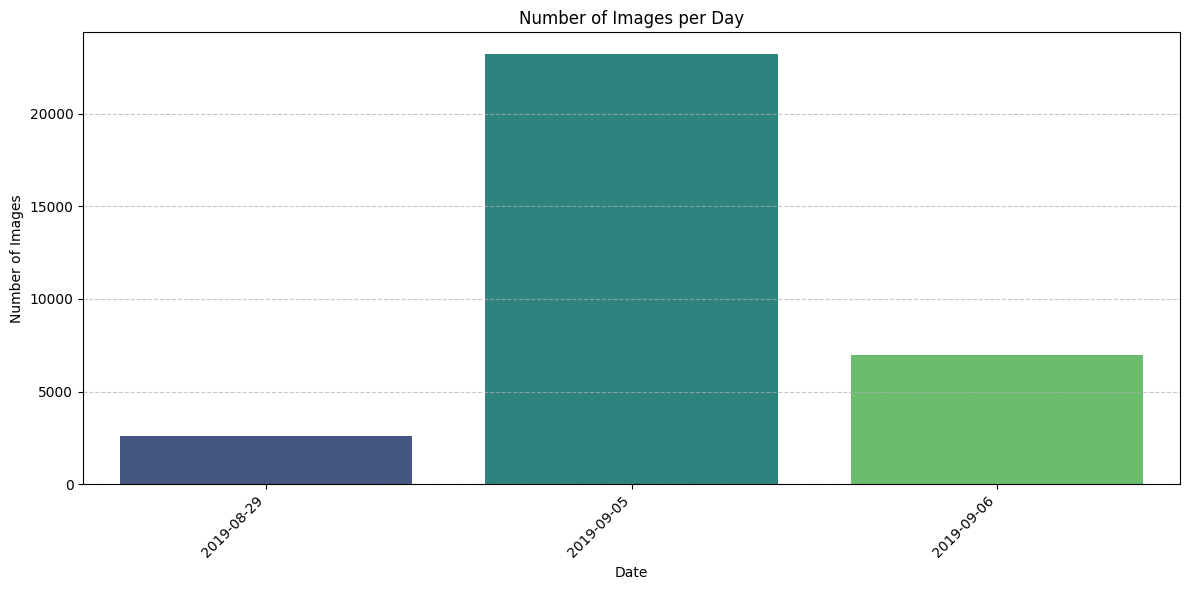

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'timestamp' to datetime objects if not already
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract the date part and count unique days
daily_counts = df['timestamp'].dt.date.value_counts().sort_index()

# Create a DataFrame for plotting
daily_counts_df = daily_counts.reset_index()
daily_counts_df.columns = ['Date', 'Number of Images']

# Plot the unique days
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='Date', y='Number of Images', data=daily_counts_df, ax=ax, palette='viridis')
ax.set_title('Number of Images per Day')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Most of the images have been captured in 5.9.2019

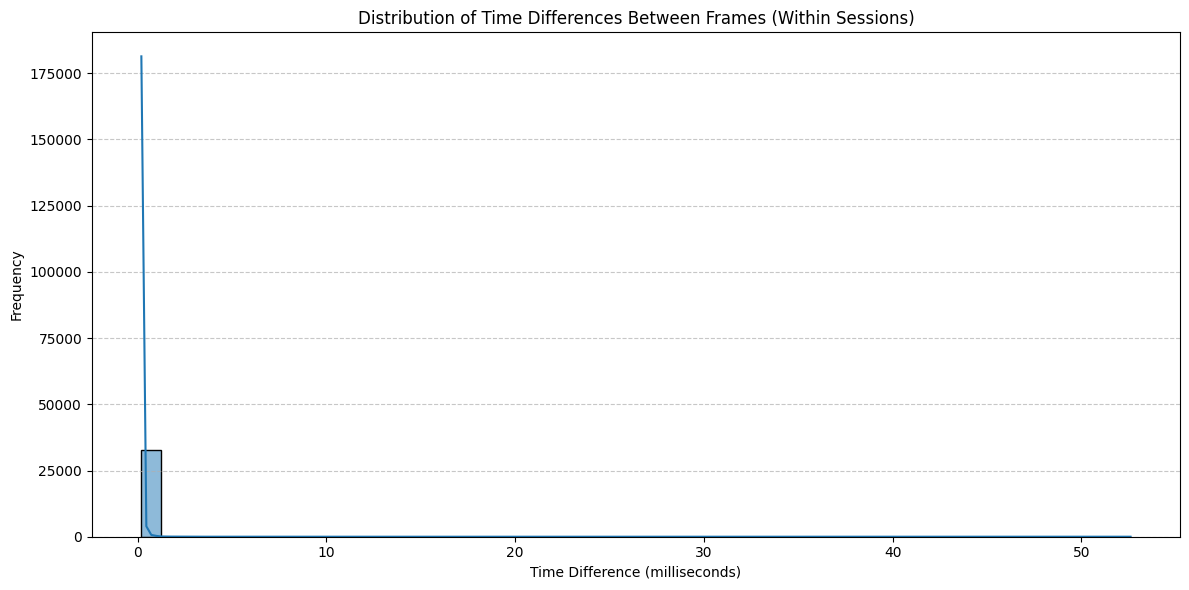

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of time differences within sessions
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(within_session['time_diff_ms'], bins=50, kde=True, ax=ax)
ax.set_title('Distribution of Time Differences Between Frames (Within Sessions)')
ax.set_xlabel('Time Difference (milliseconds)')
ax.set_ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

it appears there's a strong peak around a very low millisecond value (likely around 0.2-0.3 ms, as indicated by the summary statistics). This suggests that within recording sessions, the images were captured at a very high and consistent frame rate, with very little time delay between consecutive frames.

This histogram shows that within recording sessions, the images were captured at a very high and consistent frame rate, with a strong peak around a very low millisecond value (around 0.2-0.3 ms), indicating minimal delay between consecutive frames.

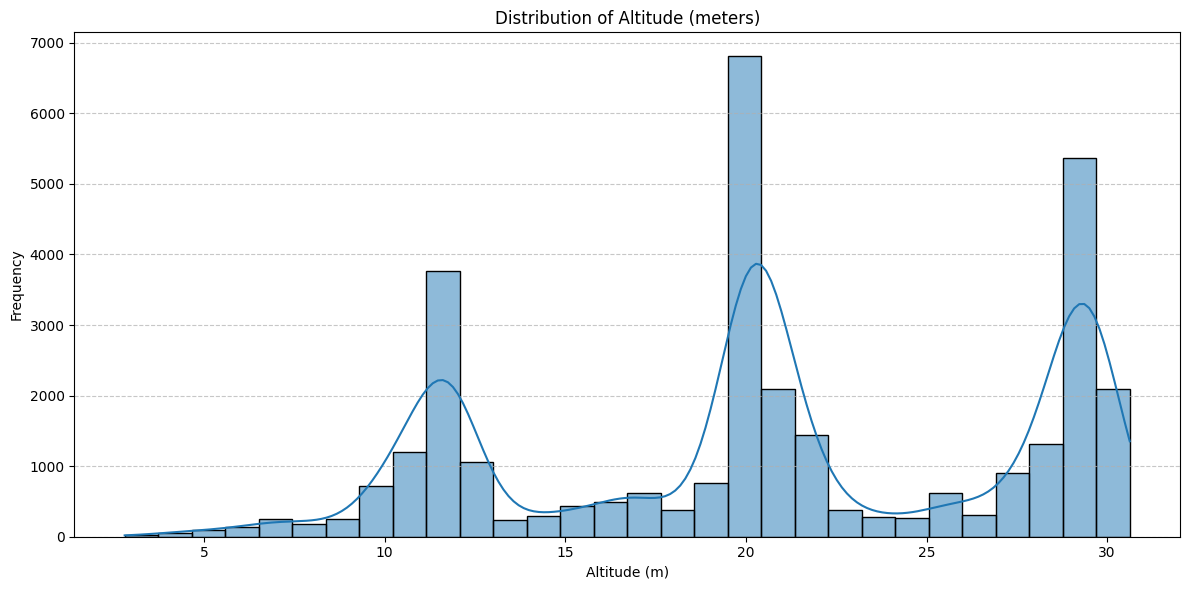

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of altitude
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(df['altitude_m'], bins=30, kde=True, ax=ax)
ax.set_title('Distribution of Altitude (meters)')
ax.set_xlabel('Altitude (m)')
ax.set_ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2087/526866874.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='date_only', y='altitude_m', data=df, palette='viridis', ax=ax)


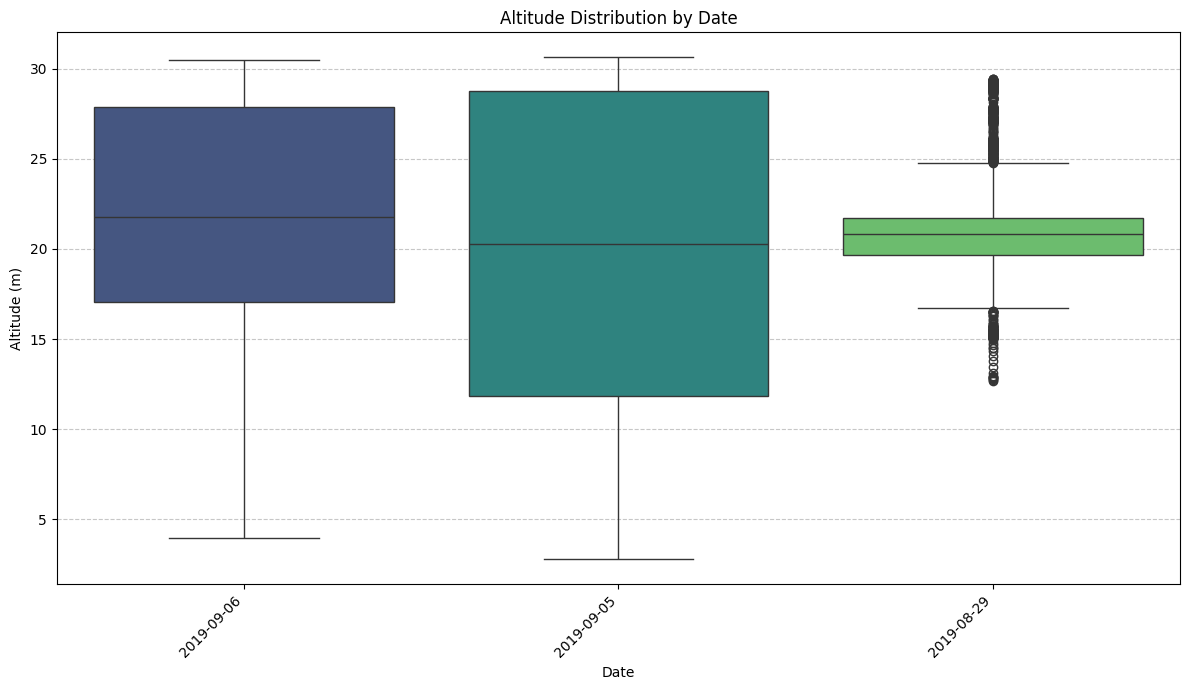

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot of 'altitude_m' grouped by 'date_only'
fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(x='date_only', y='altitude_m', data=df, palette='viridis', ax=ax)
ax.set_title('Altitude Distribution by Date')
ax.set_xlabel('Date')
ax.set_ylabel('Altitude (m)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

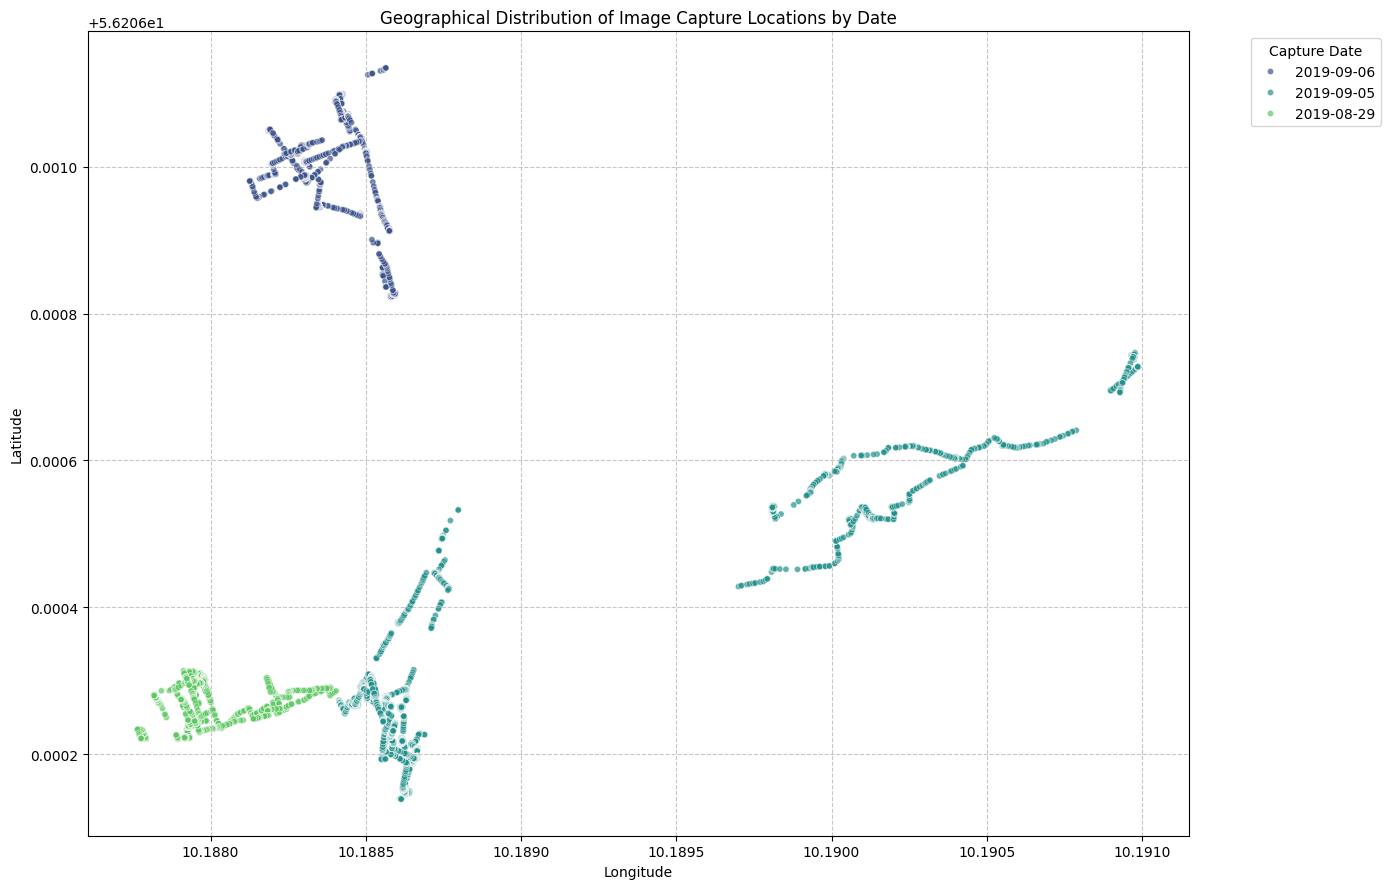

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'timestamp' is datetime and extract the date for coloring
df['date_only'] = df['timestamp'].dt.date

# Create a scatter plot of longitude vs. latitude, colored by date
fig, ax = plt.subplots(figsize=(14, 9)) # Slightly larger figure for legend
sns.scatterplot(x='longitude', y='latitude', data=df, s=20, alpha=0.7, hue='date_only', palette='viridis', ax=ax)
ax.set_title('Geographical Distribution of Image Capture Locations by Date')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Capture Date', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside
plt.tight_layout()
plt.show()

this scatter plot shows that the dataset can be clusttered into almost 4 clusters. The first one is of the date 6.9.2019, 5.9.2019, and 29.8.2019 and another location of the date 5.9.2019 | we can also consider the right (x shape) as another seperate cluster.

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

# Prepare the data for clustering
X = df[['longitude', 'latitude']].values

# Apply K-Means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # n_init explicitly set to avoid warning
df['cluster_label'] = kmeans.fit_predict(X)

print("K-Means clustering performed successfully. Cluster labels added to DataFrame.")

K-Means clustering performed successfully. Cluster labels added to DataFrame.


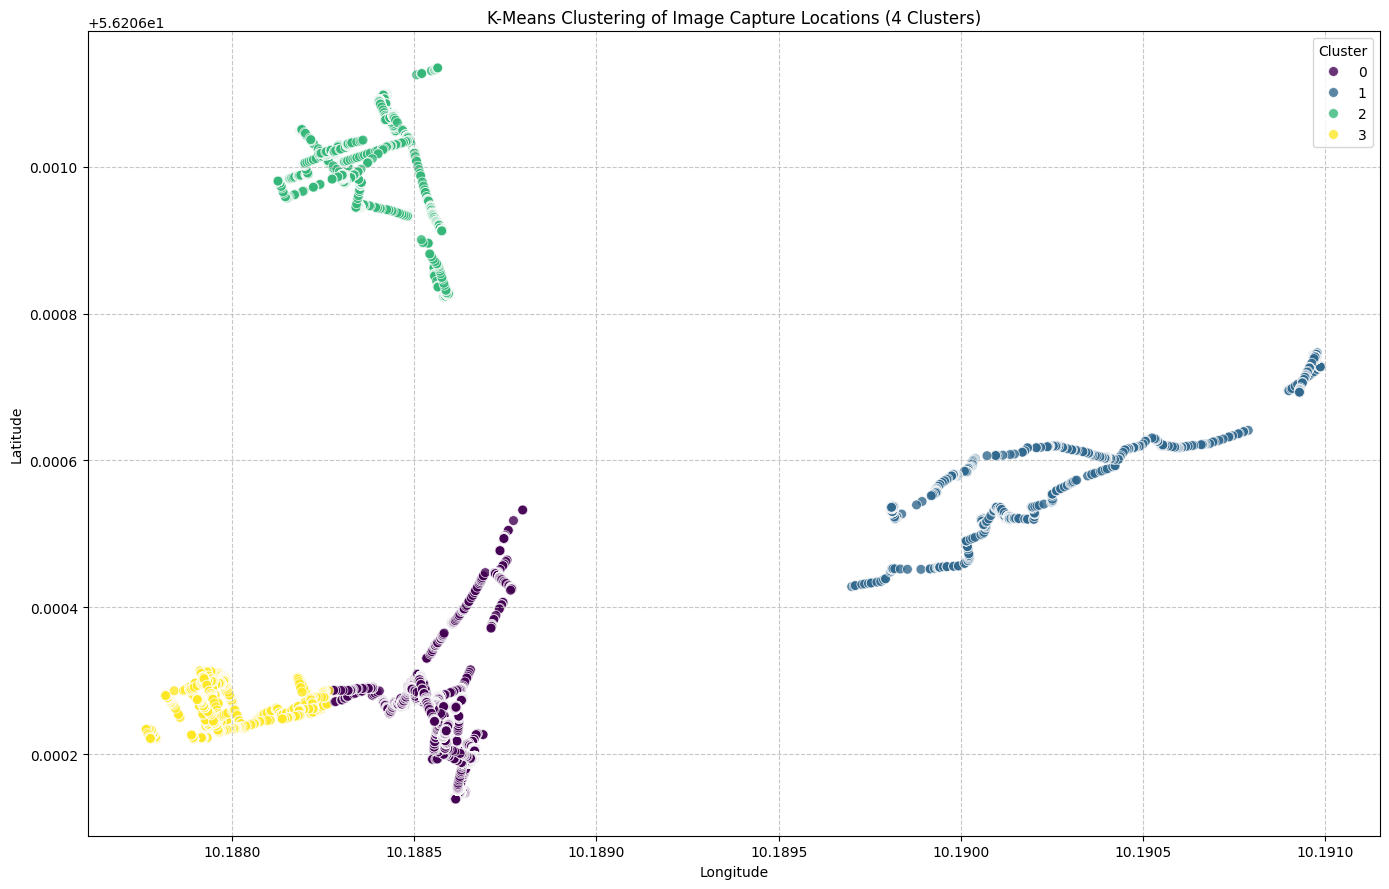

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the clusters
fig, ax = plt.subplots(figsize=(14, 9))
sns.scatterplot(x='longitude', y='latitude', hue='cluster_label', data=df, palette='viridis', s=50, alpha=0.8, ax=ax)
ax.set_title('K-Means Clustering of Image Capture Locations (4 Clusters)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

Clusters using K-means -> results in 4 clusters

## Classes

    class_id   count
0        Car  102619
1        Van    9995
2      Truck    9545
3      Human    5158
4    Trailer    2538
5    Bicycle    1128
6        Bus     729
7  Motorbike     319


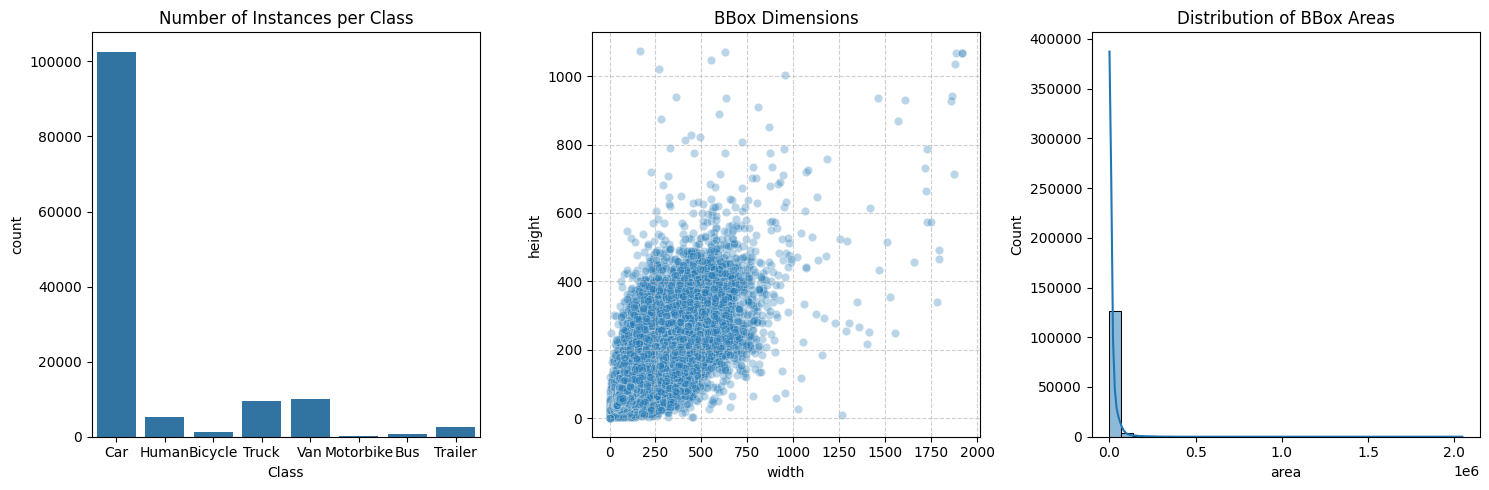

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Note: We are using the 'sorted_annotations' variable already loaded and processed by the AUAIR object
# and defined in a previous cell, as it provides the correctly structured data.

# 2. Extract relevant info into a DataFrame
annotations_data = []
for frame_ann in sorted_annotations: # Iterate through the processed sorted_annotations
    # Each frame_ann can contain multiple object bounding boxes under the 'bbox' key
    if 'bbox' in frame_ann and isinstance(frame_ann['bbox'], list):
        for obj_bbox_dict in frame_ann['bbox']:
            # Each objobj_bbox_dict is expected to be a dictionary: {'top': ..., 'left': ..., 'height': ..., 'width': ..., 'class': ...}
            if isinstance(obj_bbox_dict, dict) and \
               'width' in obj_bbox_dict and \
               'height' in obj_bbox_dict and \
               'class' in obj_bbox_dict:

                w = obj_bbox_dict['width']
                h = obj_bbox_dict['height']
                class_id = obj_bbox_dict['class'] # Access 'class' key for class_id
                if class_id == 0:
                    class_id = 'Human'
                elif class_id == 1:
                    class_id = 'Car'
                elif class_id == 2:
                    class_id = 'Truck'
                elif class_id == 3:
                    class_id = 'Van'
                elif class_id == 4:
                    class_id = 'Motorbike'
                elif class_id == 5:
                    class_id = 'Bicycle'
                elif class_id == 6:
                    class_id = 'Bus'
                elif class_id == 7:
                    class_id = 'Trailer'
                else :
                    class_id = 'Unknown'

                annotations_data.append({
                    'class_id': class_id,
                    'width': w,
                    'height': h,
                    'area': w * h
                })

df1 = pd.DataFrame(annotations_data)

# 3. Plotting
plt.figure(figsize=(15, 5))

# print each class and its number of instances in a. table
class_counts = df1['class_id'].value_counts().reset_index()
class_counts.columns = ['class_id', 'count']
print(class_counts)

# Plot A: Class Distribution
plt.subplot(1, 3, 1)
sns.countplot(data=df1, x='class_id')
plt.title('Number of Instances per Class')
plt.xlabel('Class')

# Plot B: BBox Aspect Ratio (Width vs Height)
plt.subplot(1, 3, 2)
sns.scatterplot(data=df1, x='width', y='height', alpha=0.3)
plt.title('BBox Dimensions')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot C: Distribution of Box Areas
plt.subplot(1, 3, 3)
sns.histplot(df1['area'], bins=30, kde=True)
plt.title('Distribution of BBox Areas')

plt.tight_layout()
plt.show()

### Checking for duplicate timestamps

In [ ]:
df.head()

,class_id,width,height,area
0,Car,81,32,2592
1,Car,86,73,6278
2,Human,41,46,1886
3,Human,34,63,2142
4,Human,35,45,1575


In [ ]:
# Check for unique timestamps
num_unique_timestamps = df['timestamp'].nunique()
total_images = len(df)

print(f"Total images: {total_images}")
print(f"Number of unique timestamps: {num_unique_timestamps}")

if num_unique_timestamps < total_images:
    print("\nDuplicate timestamps found!")
    duplicate_timestamps = df['timestamp'].value_counts()
    duplicate_timestamps = duplicate_timestamps[duplicate_timestamps > 1]
    print("\nTimestamps with duplicates and their counts:")
    display(duplicate_timestamps.head())
else:
    print("\nAll timestamps are unique.")

KeyError: 'timestamp'

## INTERVAL

In [9]:
# N_array =[] # from 10 % to 90 %
# n = len(df) # total number of images
# k = [10,20,30,40,50,60,70,80,90,100]
# time_diff = df['time_diff_sec'].mode()
# intervals = []
# for i in k:
#   N = int(n * (i/100))
#   N_array.append(N)
#   # print(f"N = {N} | iteration {i}")
#   intrvl = int(time_diff * N *100)
#   # print(f"Interval = {intrvl}")
#   intervals.append(intrvl)

# print(f"N = {N_array}")
# print(f"K = {k}")
# intervals.sort(reverse = True)
# print(f"Interval = {intervals}")


N_array = []
n = len(df)
k = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
time_diff = df['time_diff_sec'].mode()[0]  # extract scalar from Series
intervals = []

if time_diff >= 1:
    time_diff /= 10000

for i in k:
    N = int(n * (i / 100))
    N_array.append(N)
    intrvl = int(time_diff * N * 100)
    intervals.append(intrvl)

print(f"N = {N_array}")
print(f"K = {k}")
intervals.sort(reverse=True)
print(f"Interval = {intervals}")

N = [3282, 6564, 9846, 13129, 16411, 19693, 22976, 26258, 29540, 32823]
K = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
Interval = [656, 590, 525, 459, 393, 328, 262, 196, 131, 65]


In [10]:
def hmie(df, k, N_array, intervals):
    images_list = []
    master_images = {}
    print("Starting the algorithm ....")

    for a in range(len(k)):
        intrvl = intervals[a]
        subset_dataset = N_array[a]
        percent = k[a]
        images_list = []

        print(f"Starting subset for percent={percent}, n={subset_dataset}, interval={intrvl} ....")

        i = 0  # Start from the first index
        for x in range(subset_dataset):
            # print(f"Picking image at index {i}")
            images_list.append(df['image_name'][i])

            i += intrvl  # Jump by interval

            # Wrap around if we exceed the dataset length
            if i >= len(df):
                i = (i % len(df)) + 1  # Wrap and offset to avoid repeating index 0

        print(f"percent={percent}, subset_dataset={subset_dataset}, intrvl={intrvl}")

        master_images[a] = images_list  # Correctly store in dict

    return master_images


In [11]:
master_images = hmie(df, k, N_array, intervals)

Starting the algorithm ....
Starting subset for percent=10, n=3282, interval=656 ....
percent=10, subset_dataset=3282, intrvl=656
Starting subset for percent=20, n=6564, interval=590 ....
percent=20, subset_dataset=6564, intrvl=590
Starting subset for percent=30, n=9846, interval=525 ....
percent=30, subset_dataset=9846, intrvl=525
Starting subset for percent=40, n=13129, interval=459 ....
percent=40, subset_dataset=13129, intrvl=459
Starting subset for percent=50, n=16411, interval=393 ....
percent=50, subset_dataset=16411, intrvl=393
Starting subset for percent=60, n=19693, interval=328 ....
percent=60, subset_dataset=19693, intrvl=328
Starting subset for percent=70, n=22976, interval=262 ....
percent=70, subset_dataset=22976, intrvl=262
Starting subset for percent=80, n=26258, interval=196 ....
percent=80, subset_dataset=26258, intrvl=196
Starting subset for percent=90, n=29540, interval=131 ....
percent=90, subset_dataset=29540, intrvl=131
Starting subset for percent=100, n=32823, 

In [12]:
for i in master_images:
  print("Split ",i+1, "-->", len(master_images[i]), "\n")


Split  1 --> 3282 

Split  2 --> 6564 

Split  3 --> 9846 

Split  4 --> 13129 

Split  5 --> 16411 

Split  6 --> 19693 

Split  7 --> 22976 

Split  8 --> 26258 

Split  9 --> 29540 

Split  10 --> 32823 



## Save into splits.csv

In [ ]:
# Write the subset to a csv file for future analyzation
rows = []
for a, images in master_images.items():
    percent = k[a]
    for image_name in images:
        rows.append({'image_name': image_name, 'percent': percent})

result_df = pd.DataFrame(rows, columns=['image_name', 'percent'])
result_df.to_csv('/content/drive/MyDrive/auair/splits.csv', index=False)
print("Saved to splits.csv")

Saved to splits.csv


# READ SPLITS

In [12]:
data = pd.read_csv('/content/drive/MyDrive/auair/splits.csv')
data.head()

,image_name,percent
0,frame_20190906150731_x_0000093.jpg,10
1,frame_20190906150731_x_0000789.jpg,10
2,frame_20190906150731_x_0001450.jpg,10
3,frame_20190906150731_x_0002129.jpg,10
4,frame_20190906150731_x_0002798.jpg,10


## Split function

In [13]:
def split(data, percent):

  images = data[data['percent'] == percent]['image_name'].tolist()
  train_images = images[:int(len(images) * 0.8)]
  test_images = images[int(len(images) * 0.8):]

  return train_images, test_images



In [49]:
percent = 70
train_split, test_split = split(data, percent)
print(f"Train lenth = {len(train_split)} \nTest lenth = {len(test_split)}\nTotal = {len(test_split)+len(train_split)}")

Train lenth = 18380 
Test lenth = 4596
Total = 22976


In [22]:
print(test_split)

['frame_20190905112522_x_0003144.jpg', 'frame_20190905112522_x_0003340.jpg', 'frame_20190905112522_x_0003539.jpg', 'frame_20190905112522_x_0003740.jpg', 'frame_20190905112522_x_0003952.jpg', 'frame_20190905112522_x_0004221.jpg', 'frame_20190905112522_x_0004470.jpg', 'frame_20190905112522_x_0004722.jpg', 'frame_20190905112522_x_0004970.jpg', 'frame_20190905112522_x_0005177.jpg', 'frame_20190905112522_xx_0000139.jpg', 'frame_20190905112522_xx_0000343.jpg', 'frame_20190905112522_xx_0000620.jpg', 'frame_20190905111947_x_0000224.jpg', 'frame_20190905111947_x_0000420.jpg', 'frame_20190905111947_x_0000616.jpg', 'frame_20190905111947_x_0000815.jpg', 'frame_20190905103112_x_0000190.jpg', 'frame_20190905103112_x_0000467.jpg', 'frame_20190905103112_x_0000669.jpg', 'frame_20190905103112_x_0000871.jpg', 'frame_20190905103112_x_0001068.jpg', 'frame_20190905103112_x_0001270.jpg', 'frame_20190905103112_x_0001476.jpg', 'frame_20190905103112_x_0001673.jpg', 'frame_20190905103112_x_0001870.jpg', 'frame_2

### Convert JSON to YOLO Format

In [19]:
import json
import os
import shutil
import pandas as pd
from pathlib import Path

def convert_auair_to_yolo(auair_annotations, images_dir, output_dir, split_csv, filter_percent=None, train_img_names=None, test_img_names=None):
    split_df = pd.read_csv(split_csv)

    # Filter for the specific percent if provided
    if filter_percent is not None:
        split_df = split_df[split_df['percent'] == filter_percent]

    image_name_to_annotation = {ann['image_name']: ann for ann in auair_annotations}

    # Define class ID remapping based on the user's explicit request in cell 8_0c-3sjaQIj
    # Class ID 3 (Truck) will be remapped to Class ID 2 (Truck)
    class_id_remap = {
        0: 0,  # Human
        1: 1,  # Car
        2: 2,  # Truck
        3: 3,  # Van
        4: 4,  # Motorbike
        5: 5,  # Bicycle
        6: 6,  # Bus
        7: 7   # Trailer
    }
    # These will be the final class names corresponding to the remapped IDs (0-6)
    final_class_names = ['Human', 'Car', 'Truck','Van','Motorbike', 'Bicycle', 'Bus', 'Trailer']
    nc = len(final_class_names)

    for percent_val in split_df['percent'].unique():
        # Base output path for this split percentage
        base_split_out_dir = Path(output_dir) / f"split_{percent_val}"

        # Create YOLO folder structure for train and val/test
        # We will use 'train' and 'val' for the directories
        train_img_out = base_split_out_dir / "train" / "images"
        train_lbl_out = base_split_out_dir / "train" / "labels"
        train_img_out.mkdir(parents=True, exist_ok=True)
        train_lbl_out.mkdir(parents=True, exist_ok=True)

        val_img_out = base_split_out_dir / "val" / "images"
        val_lbl_out = base_split_out_dir / "val" / "labels"
        val_img_out.mkdir(parents=True, exist_ok=True)
        val_lbl_out.mkdir(parents=True, exist_ok=True)

        # Get all images for this split percent from split_df
        all_split_images = set(split_df[split_df['percent'] == percent_val]['image_name'].tolist())

        processed_train_count = 0
        processed_val_count = 0

        # Process training images
        if train_img_names is not None:
            print(f"Processing training images for split {percent_val}%...")
            for image_name in train_img_names:
                if image_name not in all_split_images:
                    # print(f"Warning: Training image {image_name} not found in current split's images. Skipping.")
                    continue
                img_ann = image_name_to_annotation.get(image_name)
                if img_ann is None:
                    print(f"Warning: Annotation for training image {image_name} not found. Skipping.")
                    continue

                W = img_ann.get('image_width:', img_ann.get('image_width', 0))
                H = img_ann.get('image_height', 0)
                if W == 0 or H == 0:
                    print(f"Warning: Training image {image_name} has invalid dimensions ({W}x{H}). Skipping.")
                    continue

                source_image_path = Path(images_dir) / image_name
                if not source_image_path.exists():
                    print(f"Warning: Source image file {source_image_path} not found. Skipping {image_name}.")
                    continue

                shutil.copy(source_image_path, train_img_out / image_name)
                label_path = train_lbl_out / (Path(image_name).stem + '.txt')
                bboxes = img_ann.get('bbox', [])

                with open(label_path, 'w') as f:
                    for bbox_obj in bboxes:
                        x_top_left = bbox_obj['left']
                        y_top_left = bbox_obj['top']
                        w_bbox = bbox_obj['width']
                        h_bbox = bbox_obj['height']
                        original_class_id = bbox_obj['class']

                        # Apply remapping
                        remapped_class_id = class_id_remap.get(original_class_id, original_class_id)
                        if remapped_class_id >= nc:
                            print(f"Warning: Class ID {original_class_id} remapped to {remapped_class_id} which is out of range for {nc} classes. Skipping bbox.")
                            continue

                        center_x = (x_top_left + w_bbox / 2) / W
                        center_y = (y_top_left + h_bbox / 2) / H
                        norm_w = w_bbox / W
                        norm_h = h_bbox / H

                        center_x = max(0.0, min(1.0, center_x))
                        center_y = max(0.0, min(1.0, center_y))
                        norm_w = max(0.0, min(1.0, norm_w))
                        norm_h = max(0.0, min(1.0, norm_h))

                        f.write(f"{remapped_class_id} {center_x:.6f} {center_y:.6f} {norm_w:.6f} {norm_h:.6f}\n")
                        processed_train_count += 1

            print(f"Split {percent_val}%: Converted {processed_train_count} training images out of {len(train_img_names)} requested for training.")

        # Process test images (which will be used for validation here)
        if test_img_names is not None:
            print(f"Processing validation images for split {percent_val}%...")
            for image_name in test_img_names:
                if image_name not in all_split_images:
                    print(f"Warning: Test image {image_name} not found in current split's images. Skipping.")
                    continue
                img_ann = image_name_to_annotation.get(image_name)
                if img_ann is None:
                    print(f"Warning: Annotation for test image {image_name} not found. Skipping.")
                    continue

                W = img_ann.get('image_width:', img_ann.get('image_width', 0))
                H = img_ann.get('image_height', 0)
                if W == 0 or H == 0:
                    print(f"Warning: Test image {image_name} has invalid dimensions ({W}x{H}). Skipping.")
                    continue

                source_image_path = Path(images_dir) / image_name
                if not source_image_path.exists():
                    print(f"Warning: Source image file {source_image_path} not found. Skipping {image_name}.")
                    continue

                shutil.copy(source_image_path, val_img_out / image_name)
                label_path = val_lbl_out / (Path(image_name).stem + '.txt')
                bboxes = img_ann.get('bbox', [])

                with open(label_path, 'w') as f:
                    for bbox_obj in bboxes:
                        x_top_left = bbox_obj['left']
                        y_top_left = bbox_obj['top']
                        w_bbox = bbox_obj['width']
                        h_bbox = bbox_obj['height']
                        original_class_id = bbox_obj['class']

                        # Apply remapping
                        remapped_class_id = class_id_remap.get(original_class_id, original_class_id)
                        if remapped_class_id >= nc:
                            print(f"Warning: Class ID {original_class_id} remapped to {remapped_class_id} which is out of range for {nc} classes. Skipping bbox.")
                            continue

                        center_x = (x_top_left + w_bbox / 2) / W
                        center_y = (y_top_left + h_bbox / 2) / H
                        norm_w = w_bbox / W
                        norm_h = h_bbox / H

                        center_x = max(0.0, min(1.0, center_x))
                        center_y = max(0.0, min(1.0, center_y))
                        norm_w = max(0.0, min(1.0, norm_w))
                        norm_h = max(0.0, min(1.0, norm_h))

                        f.write(f"{remapped_class_id} {center_x:.6f} {center_y:.6f} {norm_w:.6f} {norm_h:.6f}\n")
                processed_val_count += 1
            print(f"Split {percent_val}%: Converted {processed_val_count} validation images out of {len(test_img_names)} requested for validation.")
    return nc, final_class_names # Return these for data.yaml generation

# PATH

In [24]:

coco_json_path = '/content/drive/MyDrive/au_air_labels/annotations.json'
images_dir = '/content/drive/MyDrive/au_air_data/images'
output_dir = '/content/drive/MyDrive/auair/splits'
split_csv = '/content/drive/MyDrive/auair/splits.csv'
names = ['Human', 'Car','Truck', 'Van', 'Motorbike', 'Bicycle', 'Bus', 'Trailer']
# Define the path for the data.yaml file
data_yaml_path = f"{output_dir}/split_{percent}/data.yaml"

## Convert to YOLO Format

In [30]:
# Call the updated function with train_split and test_split
nc, names = convert_auair_to_yolo(sorted_annotations, images_dir, output_dir, split_csv, percent_val=percent, train_img_names=train_split, test_img_names=test_split)

Processing training images for split 10%...


KeyboardInterrupt: 

## Verify

In [44]:
def verify_yolo_conversion(output_dir, train_img_names, test_img_names, filter_percent=None):
    output_dir = Path(output_dir)

    # Find all split directories
    split_dirs = sorted([d for d in output_dir.iterdir() if d.is_dir() and d.name.startswith("split_")])

    if not split_dirs:
        print("No split directories found in output_dir.")
        return

    all_passed = True

    for split_dir in split_dirs:
        percent_val = split_dir.name.replace("split_", "")

        if filter_percent is not None and str(filter_percent) != percent_val:
            continue

        train_images_dir = split_dir / "train" / "images"
        val_images_dir   = split_dir / "val"   / "images"

        actual_train = len(list(train_images_dir.iterdir())) if train_images_dir.exists() else 0
        actual_val   = len(list(val_images_dir.iterdir()))   if val_images_dir.exists()   else 0

        expected_train = len(train_img_names) if train_img_names is not None else 0
        expected_val   = len(test_img_names)  if test_img_names  is not None else 0

        train_ok = actual_train == expected_train
        val_ok   = actual_val   == expected_val

        train_status = "✅ PASS" if train_ok else "❌ FAIL"
        val_status   = "✅ PASS" if val_ok   else "❌ FAIL"

        print(f"--- Split {percent_val}% ---")
        print(f"  Train  | Expected: {expected_train:>5}  | Actual: {actual_train:>5}  | {train_status}")
        print(f"  Val    | Expected: {expected_val:>5}  | Actual: {actual_val:>5}  | {val_status}")

        if not train_ok:
            diff = expected_train - actual_train
            print(f"  ⚠️  Train mismatch: {abs(diff)} image(s) {'missing' if diff > 0 else 'extra'}")
        if not val_ok:
            diff = expected_val - actual_val
            print(f"  ⚠️  Val mismatch: {abs(diff)} image(s) {'missing' if diff > 0 else 'extra'}")

        if not (train_ok and val_ok):
            all_passed = False

    print()
    print("Overall:", "✅ All checks passed." if all_passed else "❌ Some checks failed.")
    return all_passed

In [45]:
verify_yolo_conversion(output_dir,train_split,test_split,percent)

--- Split 70% ---
  Train  | Expected: 18380  | Actual: 16412  | ❌ FAIL
  Val    | Expected:  4596  | Actual:  4596  | ✅ PASS
  ⚠️  Train mismatch: 1968 image(s) missing

Overall: ❌ Some checks failed.


False

In [63]:
import os
l = len(os.listdir('/content/drive/MyDrive/auair/splits/split_70/train/images'))

m = len(os.listdir('/content/drive/MyDrive/auair/splits/split_70/val/images'))
print(l+m)

21008


In [64]:
print(l)
print(m)

16412
4596


## Recover missing images

In [61]:
# def reover(split_csv, train_split, test_split):
split_df = pd.read_csv(split_csv)
my_df = split_df[split_df['percent'] == percent]
print(len(my_df))

22976


In [46]:
def recover_missing_yolo_images(auair_annotations, images_dir, output_dir, split_csv,
                                 train_img_names, test_img_names, filter_percent=None):
    output_dir = Path(output_dir)
    split_df = pd.read_csv(split_csv)

    if filter_percent is not None:
        split_df = split_df[split_df['percent'] == filter_percent]

    image_name_to_annotation = {ann['image_name']: ann for ann in auair_annotations}

    class_id_remap = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7}
    final_class_names = ['Human', 'Car', 'Truck', 'Van', 'Motorbike', 'Bicycle', 'Bus', 'Trailer']
    nc = len(final_class_names)

    for percent_val in split_df['percent'].unique():
        base_split_out_dir = output_dir / f"split_{percent_val}"

        train_img_out = base_split_out_dir / "train" / "images"
        train_lbl_out = base_split_out_dir / "train" / "labels"
        val_img_out   = base_split_out_dir / "val"   / "images"
        val_lbl_out   = base_split_out_dir / "val"   / "labels"

        # Already converted images
        already_train = {f.name for f in train_img_out.iterdir()} if train_img_out.exists() else set()
        already_val   = {f.name for f in val_img_out.iterdir()}   if val_img_out.exists()   else set()

        # Find missing images
        missing_train = [n for n in (train_img_names or []) if n not in already_train]
        missing_val   = [n for n in (test_img_names  or []) if n not in already_val]

        print(f"--- Split {percent_val}% ---")
        print(f"  Missing train: {len(missing_train)} | Missing val: {len(missing_val)}")

        if not missing_train and not missing_val:
            print("  ✅ Nothing to recover.")
            continue

        all_split_images = set(split_df[split_df['percent'] == percent_val]['image_name'].tolist())

        # Ensure output dirs exist
        train_img_out.mkdir(parents=True, exist_ok=True)
        train_lbl_out.mkdir(parents=True, exist_ok=True)
        val_img_out.mkdir(parents=True, exist_ok=True)
        val_lbl_out.mkdir(parents=True, exist_ok=True)

        def process_image(image_name, img_out, lbl_out):
            """Attempt to convert a single image, return (success, reason_if_failed)."""
            if image_name not in all_split_images:
                return False, "not in split CSV"

            img_ann = image_name_to_annotation.get(image_name)
            if img_ann is None:
                return False, "no annotation found"

            W = img_ann.get('image_width:', img_ann.get('image_width', 0))
            H = img_ann.get('image_height', 0)
            if W == 0 or H == 0:
                return False, f"invalid dimensions ({W}x{H})"

            source_image_path = Path(images_dir) / image_name
            if not source_image_path.exists():
                return False, f"source file not found at {source_image_path}"

            shutil.copy(source_image_path, img_out / image_name)
            label_path = lbl_out / (Path(image_name).stem + '.txt')
            bboxes = img_ann.get('bbox', [])

            with open(label_path, 'w') as f:
                for bbox_obj in bboxes:
                    x_top_left = bbox_obj['left']
                    y_top_left = bbox_obj['top']
                    w_bbox     = bbox_obj['width']
                    h_bbox     = bbox_obj['height']
                    original_class_id = bbox_obj['class']

                    remapped_class_id = class_id_remap.get(original_class_id, original_class_id)
                    if remapped_class_id >= nc:
                        continue

                    center_x = max(0.0, min(1.0, (x_top_left + w_bbox / 2) / W))
                    center_y = max(0.0, min(1.0, (y_top_left + h_bbox / 2) / H))
                    norm_w   = max(0.0, min(1.0, w_bbox / W))
                    norm_h   = max(0.0, min(1.0, h_bbox / H))

                    f.write(f"{remapped_class_id} {center_x:.6f} {center_y:.6f} {norm_w:.6f} {norm_h:.6f}\n")

            return True, None

        # Recover train
        recovered_train, failed_train = 0, []
        for image_name in missing_train:
            success, reason = process_image(image_name, train_img_out, train_lbl_out)
            if success:
                recovered_train += 1
            else:
                failed_train.append((image_name, reason))

        # Recover val
        recovered_val, failed_val = 0, []
        for image_name in missing_val:
            success, reason = process_image(image_name, val_img_out, val_lbl_out)
            if success:
                recovered_val += 1
            else:
                failed_val.append((image_name, reason))

        # Report
        print(f"  Train — Recovered: {recovered_train} | Unrecoverable: {len(failed_train)}")
        for name, reason in failed_train:
            print(f"    ❌ {name}: {reason}")

        print(f"  Val   — Recovered: {recovered_val} | Unrecoverable: {len(failed_val)}")
        for name, reason in failed_val:
            print(f"    ❌ {name}: {reason}")

In [52]:
recover_missing_yolo_images(
    auair_annotations= sorted_annotations,
    images_dir=images_dir,
    output_dir=output_dir,
    split_csv=split_csv,
    train_img_names=train_split,
    test_img_names=test_split,
    filter_percent=70  # optional
)

--- Split 70% ---
  Missing train: 0 | Missing val: 0
  ✅ Nothing to recover.


## Visualizing Ground Truth Bounding Boxes

In [ ]:
import cv2
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

# Assuming `sorted_annotations`, `images_dir`, `test_split`, `output_dir`, `percent`, and `names` are available from previous cells.
# `names` is the list of class names generated during YOLO conversion.

# Create a dictionary for quick lookup of annotations by image name
annotation_map = {ann['image_name']: ann for ann in sorted_annotations}

# Select a few random images from the test_split to visualize
num_images_to_show = 3
selected_test_images = random.sample(test_split, min(num_images_to_show, len(test_split)))

print(f"Displaying ground truth bounding boxes for {len(selected_test_images)} images from the test set (from JSON annotations)...")

for img_name in selected_test_images:
    img_path = os.path.join(images_dir, img_name)

    if not os.path.exists(img_path):
        print(f"Error: Image file not found for {img_name} at {img_path}. Skipping.")
        continue

    img_ann = annotation_map.get(img_name)
    if img_ann is None:
        print(f"Error: Annotations not found for {img_name}. Skipping.")
        continue

    # Load the image using OpenCV
    image = cv2.imread(img_path)
    if image is None:
        print(f"Error: Could not load image {img_path}. Skipping.")
        continue

    # OpenCV loads images in BGR format, convert to RGB for matplotlib/PIL display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Get image dimensions (from annotation or loaded image)
    # Prefer annotation dimensions if consistent, otherwise use loaded image's
    img_width = img_ann.get('image_width:', img_ann.get('image_width'))
    img_height = img_ann.get('image_height')

    # Fallback if annotation dimensions are missing or incorrect
    if img_width is None or img_height is None or img_width == 0 or img_height == 0:
        img_height, img_width, _ = image_rgb.shape

    # Draw bounding boxes
    if 'bbox' in img_ann and isinstance(img_ann['bbox'], list):
        for bbox_obj in img_ann['bbox']:
            x_top_left = bbox_obj['left']
            y_top_left = bbox_obj['top']
            w_bbox = bbox_obj['width']
            h_bbox = bbox_obj['height']
            original_class_id = bbox_obj['class']

            # Remap class ID to match the `names` list if necessary (from convert_auair_to_yolo function)
            remapped_class_id = original_class_id # Assuming names correspond to original class IDs or adjust as per conversion
            class_label = names[remapped_class_id] if remapped_class_id < len(names) else f"Unknown Class {original_class_id}"

            # Ensure coordinates are integers for drawing
            x1 = int(x_top_left)
            y1 = int(y_top_left)
            x2 = int(x_top_left + w_bbox)
            y2 = int(y_top_left + h_bbox)

            # Draw rectangle
            color = (0, 255, 0) # Green color for bounding boxes (RGB)
            thickness = 2
            cv2.rectangle(image_rgb, (x1, y1), (x2, y2), color, thickness)

            # Put label
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 0.7
            font_thickness = 2
            text_size = cv2.getTextSize(class_label, font, font_scale, font_thickness)[0]
            text_x = x1
            text_y = y1 - 10 if y1 - 10 > text_size[1] else y1 + text_size[1] + 10 # Adjust text position
            cv2.putText(image_rgb, class_label, (text_x, text_y), font, font_scale, color, font_thickness, cv2.LINE_AA)

    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    plt.title(f"Ground Truth (JSON) for: {img_name}")
    plt.axis('off')
    plt.show()

print("\n---")
print("--- Pulling and visualizing annotations from YOLO format files ---")
# Example of pulling annotations from a YOLO format .txt file for one of the selected images
if selected_test_images:
    for idx, img_name in enumerate(selected_test_images):
      example_img_name = img_name # Take the first image from the selected list
      # Construct the path to the corresponding YOLO label file in the 'val' directory
      yolo_label_dir = os.path.join(output_dir, f"split_{percent}", "val", "labels")
      yolo_label_filename = os.path.splitext(example_img_name)[0] + '.txt'
      yolo_label_path = os.path.join(yolo_label_dir, yolo_label_filename)

      print(f"\nReading YOLO annotations for image: {example_img_name}")
      print(f"From YOLO label file: {yolo_label_path}")

      if os.path.exists(yolo_label_path):
          with open(yolo_label_path, 'r') as f:
              yolo_annotations_raw = f.readlines()

          if yolo_annotations_raw:
              print("YOLO Annotations (class_id center_x center_y width height, all normalized):")
              for line in yolo_annotations_raw:
                  parts = line.strip().split()
                  if len(parts) == 5:
                      class_id = int(parts[0])
                      center_x = float(parts[1])
                      center_y = float(parts[2])
                      norm_w = float(parts[3])
                      norm_h = float(parts[4])

                      print(f"  Class: {names[class_id] if class_id < len(names) else 'Unknown Class'} (ID: {class_id}), "
                            f"Center_X: {center_x:.4f}, Center_Y: {center_y:.4f}, "
                            f"Width: {norm_w:.4f}, Height: {norm_h:.4f}")
                  else:
                      print(f"  Malformed YOLO line: {line.strip()}")

              # Now, visualize these YOLO annotations on the image
              print(f"\nVisualizing YOLO annotations for: {example_img_name}")
              img_path_yolo = os.path.join(images_dir, example_img_name)
              image_yolo = cv2.imread(img_path_yolo)
              if image_yolo is None:
                  print(f"Error: Could not load image {img_path_yolo} for YOLO visualization. Skipping.")
              else:
                  image_yolo_rgb = cv2.cvtColor(image_yolo, cv2.COLOR_BGR2RGB)
                  img_h, img_w, _ = image_yolo_rgb.shape

                  for line in yolo_annotations_raw:
                      parts = line.strip().split()
                      if len(parts) == 5:
                          class_id = int(parts[0])
                          center_x = float(parts[1])
                          center_y = float(parts[2])
                          norm_w = float(parts[3])
                          norm_h = float(parts[4])

                          # Denormalize coordinates
                          bbox_width = int(norm_w * img_w)
                          bbox_height = int(norm_h * img_h)
                          bbox_center_x = int(center_x * img_w)
                          bbox_center_y = int(center_y * img_h)

                          x1 = int(bbox_center_x - bbox_width / 2)
                          y1 = int(bbox_center_y - bbox_height / 2)
                          x2 = int(bbox_center_x + bbox_width / 2)
                          y2 = int(bbox_center_y + bbox_height / 2)

                          class_label = names[class_id] if class_id < len(names) else f"Unknown Class {class_id}"

                          # Draw rectangle
                          color = (255, 0, 0) # Red color for YOLO bounding boxes (RGB)
                          thickness = 2
                          cv2.rectangle(image_yolo_rgb, (x1, y1), (x2, y2), color, thickness)

                          # Put label
                          font = cv2.FONT_HERSHEY_SIMPLEX
                          font_scale = 0.7
                          font_thickness = 2
                          text_size = cv2.getTextSize(class_label, font, font_scale, font_thickness)[0]
                          text_x = x1
                          text_y = y1 - 10 if y1 - 10 > text_size[1] else y1 + text_size[1] + 10 # Adjust text position
                          cv2.putText(image_yolo_rgb, class_label, (text_x, text_y), font, font_scale, color, font_thickness, cv2.LINE_AA)

                  plt.figure(figsize=(10, 10))
                  plt.imshow(image_yolo_rgb)
                  plt.title(f"Ground Truth (YOLO Format) for: {example_img_name}")
                  plt.axis('off')
                  plt.show()

          else:
              print(f"No annotations found in {yolo_label_filename}.")
      else:
          print(f"YOLO label file not found at {yolo_label_path}. Please ensure YOLO conversion was successful.")
else:
    print("No images were selected to demonstrate YOLO annotation pulling.")

Output hidden; open in https://colab.research.google.com to view.

Displaying ground truth bounding boxes for: frame_20190906150731_xx_0000616.jpg


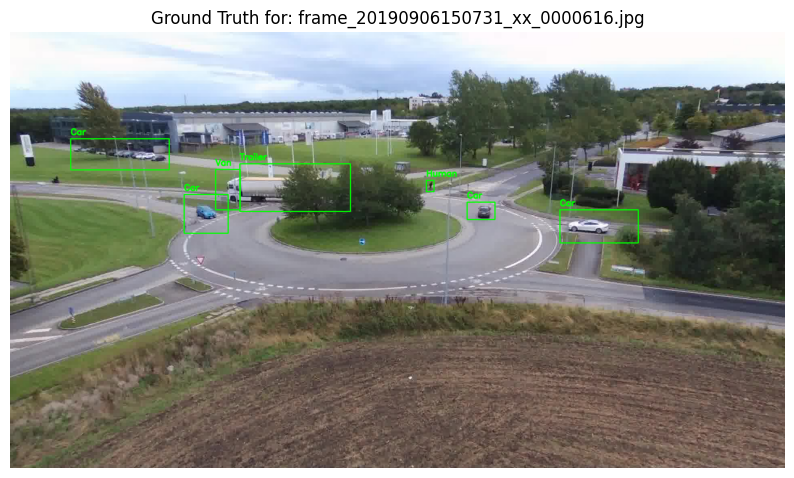

In [ ]:
import cv2
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Assuming `sorted_annotations`, `images_dir`, and `names` are available from previous cells.
# `names` is the list of class names generated during YOLO conversion.

# Create a dictionary for quick lookup of annotations by image name
annotation_map = {ann['image_name']: ann for ann in sorted_annotations}

# @title Enter the image name you want to visualize
image_name_to_visualize = 'frame_20190906150731_xx_0000616.jpg' # @param {type:"string"}

print(f"Displaying ground truth bounding boxes for: {image_name_to_visualize}")

img_path = os.path.join(images_dir, image_name_to_visualize)

if not os.path.exists(img_path):
    print(f"Error: Image file not found for {image_name_to_visualize} at {img_path}. Please check the image name and path. Skipping.")
else:
    img_ann = annotation_map.get(image_name_to_visualize)
    if img_ann is None:
        print(f"Error: Annotations not found for {image_name_to_visualize}. Skipping.")
    else:
        # Load the image using OpenCV
        image = cv2.imread(img_path)
        if image is None:
            print(f"Error: Could not load image {img_path}. Skipping.")
        else:
            # OpenCV loads images in BGR format, convert to RGB for matplotlib/PIL display
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Get image dimensions (from annotation or loaded image)
            img_width = img_ann.get('image_width:', img_ann.get('image_width'))
            img_height = img_ann.get('image_height')

            # Fallback if annotation dimensions are missing or incorrect
            if img_width is None or img_height is None or img_width == 0 or img_height == 0:
                img_height, img_width, _ = image_rgb.shape

            # Draw bounding boxes
            if 'bbox' in img_ann and isinstance(img_ann['bbox'], list):
                for bbox_obj in img_ann['bbox']:
                    x_top_left = bbox_obj['left']
                    y_top_left = bbox_obj['top']
                    w_bbox = bbox_obj['width']
                    h_bbox = bbox_obj['height']
                    original_class_id = bbox_obj['class']

                    # Remap class ID to match the `names` list if necessary (from convert_auair_to_yolo function)
                    remapped_class_id = original_class_id # Assuming names correspond to original class IDs or adjust as per conversion
                    class_label = names[remapped_class_id] if remapped_class_id < len(names) else f"Unknown Class {original_class_id}"

                    # Ensure coordinates are integers for drawing
                    x1 = int(x_top_left)
                    y1 = int(y_top_left)
                    x2 = int(x_top_left + w_bbox)
                    y2 = int(y_top_left + h_bbox)

                    # Draw rectangle
                    color = (0, 255, 0) # Green color for bounding boxes (RGB)
                    thickness = 2
                    cv2.rectangle(image_rgb, (x1, y1), (x2, y2), color, thickness)

                    # Put label
                    font = cv2.FONT_HERSHEY_SIMPLEX
                    font_scale = 0.7
                    font_thickness = 2
                    text_size = cv2.getTextSize(class_label, font, font_scale, font_thickness)[0]
                    text_x = x1
                    text_y = y1 - 10 if y1 - 10 > text_size[1] else y1 + text_size[1] + 10 # Adjust text position
                    cv2.putText(image_rgb, class_label, (text_x, text_y), font, font_scale, color, font_thickness, cv2.LINE_AA)

            # Display the image
            plt.figure(figsize=(10, 10))
            plt.imshow(image_rgb)
            plt.title(f"Ground Truth for: {image_name_to_visualize}")
            plt.axis('off')
            plt.show()

## YAML file

In [ ]:
import yaml


# Define the content of data.yaml
data_yaml_content = {
    'path': f"{output_dir}/split_{percent}", # Root path to your dataset
    'train': 'train/images',          # train images relative to 'path'
    'val': 'val/images',              # val images relative to 'path'
    'nc': nc,                         # number of classes
    'names': names                    # class names
}

# Write the data.yaml file
with open(data_yaml_path, 'w') as file:
    yaml.dump(data_yaml_content, file, default_flow_style=False)

print(f"Generated data.yaml at: {data_yaml_path}")



Generated data.yaml at: /content/drive/MyDrive/auair/splits/split_90/data.yaml


### Utlralytics (YOLOvx)

In [ ]:
!pip install -q ultralytics
from ultralytics import YOLO


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 81.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# check for the number of total images and train | test split
import os
percent= 40
pathe = f"{output_dir}/split_{percent}"
train_path = os.path.join(pathe, "train")
test_path = os.path.join(pathe, "val")
train_images = len(os.listdir(os.path.join(train_path, "images")))
test_images = len(os.listdir(os.path.join(test_path, "images")))
print(f"Total images: {train_images + test_images}")
print(f"Train images: {train_images}")
print(f"Test images: {test_images}")

Total images: 13129
Train images: 10503
Test images: 2626


## TRAIN

In [ ]:
# Load a model
model = YOLO("yolo11n.yaml")  # build a new model from YAML
model = YOLO("yolo11n.pt")  # load a pretrained model (recommended for training)
model = YOLO("yolo11n.yaml").load("yolo11n.pt")  # build from YAML and transfer weights

# Train the model
results = model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=1280,
    batch=16,
    lr0=0.01,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5,
    mosaic=0.5,
    mixup=0.0,
    degrees=0.0,
    flipud=0.5,
    fliplr=0.5,
    box=9.0,
    cls=1.5,
    plots=True,
    )

print(results)

# Save the trained model
model_save_path = f"{output_dir}/split_{percent}/best_11-200epoch.pt"
model.save(model_save_path)
print(f"Trained model saved to: {model_save_path}")

Transferred 499/499 items from pretrained weights
Ultralytics 8.4.55 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=9.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/auair/splits/split_40/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=train, nbs=64, nms=Fals

In [ ]:
!mv /content/runs/detect/train /content/drive/MyDrive/au-air_dataset/runs/detect/train-5[40%Yolo11-tuned]

mv: cannot stat '/content/runs/detect/train': No such file or directory


## Performing Inference on the Test Set

In [ ]:
import random
from PIL import Image
import numpy as np
import yaml # Import yaml to load the data.yaml

# Load the trained model
# Assuming the best model is saved at the path generated in the training cell
model_path = f"{output_dir}/split_{percent}/best_11.pt" # Changed to best_11.pt as saved in train cell
loaded_model = YOLO(model_path)
print(f"Loaded model from: {model_path}")

# Load the data.yaml file to get class names
with open(data_yaml_path, 'r') as file:
    data_config = yaml.safe_load(file)
names = data_config['names'] # Retrieve class names from data.yaml
print(f"Loaded class names: {names}")

# Get a few random images from the test_split for inference
# Ensure test_split is defined from the earlier cell or re-run if needed.
if 'test_split' not in locals():
    print("Warning: 'test_split' not found. Please run the split cell again.")
    # As a fallback, use a subset of all images if test_split is not available
    test_images_for_inference = random.sample(data['image_name'].tolist(), min(5, len(data)))
else:
    test_images_for_inference = random.sample(test_split, min(5, len(test_split)))

print("Performing inference on selected test images...")

for img_name in test_images_for_inference:
    img_path = os.path.join(images_dir, img_name)
    if not os.path.exists(img_path):
        print(f"Skipping {img_name}: Image file not found at {img_path}")
        continue

    # Perform inference
    results = loaded_model(img_path)

    # Display results (assuming `results` object has a plot method)
    for r in results:
        im_array = r.plot()  # plot a BGR numpy array of predictions
        im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
        display(im)
        print(f"Inference results for {img_name}:")
        # Print detected classes and confidence scores if available
        for box in r.boxes:
            cls = int(box.cls[0])
            conf = box.conf[0]
            label = names[cls] # Use the 'names' variable from data.yaml
            print(f"  - Detected: {label} (Class ID: {cls}), Confidence: {conf:.2f}")

Output hidden; open in https://colab.research.google.com to view.

## --------------- STATS ----------------------

In [ ]:
import os
from collections import Counter

label_dir = "/content/drive/MyDrive/auair/splits/split_30/train/labels"

class_names = ['Human', 'Car', 'Truck', 'Van', 'Motorbike', 'Bicycle', 'Bus', 'Trailer']
counter = Counter()

empty_images = 0
for fname in os.listdir(label_dir):
    if fname.endswith(".txt"):
        with open(os.path.join(label_dir, fname)) as f:
            lines = f.readlines()
            if not lines:
                empty_images += 1
            for line in lines:
                cls = int(line.split()[0])
                counter[cls] += 1

print(f"Empty label files: {empty_images}\n")
print(f"{'Class':<12} {'ID':<5} {'Count':<10} {'% of total'}")
print("-" * 40)
total = sum(counter.values())
for i, name in enumerate(class_names):
    count = counter.get(i, 0)
    pct = 100 * count / total if total > 0 else 0
    print(f"{name:<12} {i:<5} {count:<10} {pct:.1f}%")

print(f"\nTotal instances: {total}")

import os

label_dir = "/content/drive/MyDrive/auair/splits/split_30/train/labels"

widths, heights = [], []
for fname in os.listdir(label_dir):
    if fname.endswith(".txt"):
        with open(os.path.join(label_dir, fname)) as f:
            for line in f:
                parts = line.split()
                widths.append(float(parts[3]))
                heights.append(float(parts[4]))

import numpy as np
print(f"Box width  — mean: {np.mean(widths):.4f}, median: {np.median(widths):.4f}, min: {np.min(widths):.4f}, max: {np.max(widths):.4f}")
print(f"Box height — mean: {np.mean(heights):.4f}, median: {np.median(heights):.4f}, min: {np.min(heights):.4f}, max: {np.max(heights):.4f}")

tiny = sum(1 for w, h in zip(widths, heights) if w < 0.02 and h < 0.02)
print(f"\nBoxes smaller than 2% of image: {tiny} ({100*tiny/len(widths):.1f}%)")

Empty label files: 0

Class        ID    Count      % of total
----------------------------------------
Human        0     1211       3.8%
Car          1     24546      77.7%
Truck        2     2358       7.5%
Van          3     2353       7.4%
Motorbike    4     84         0.3%
Bicycle      5     285        0.9%
Bus          6     189        0.6%
Trailer      7     580        1.8%

Total instances: 31606
Box width  — mean: 0.0665, median: 0.0505, min: 0.0000, max: 0.8620
Box height — mean: 0.0787, median: 0.0630, min: 0.0000, max: 0.9917

Boxes smaller than 2% of image: 1445 (4.6%)


In [1]:
import os
l = len(os.listdir('/content/drive/MyDrive/auair/splits/split_60/train/images'))
m = len(os.listdir('/content/drive/MyDrive/auair/splits/split_60/test/images'))
print(l+m)

19693


# GROUNDING DINO

In [ ]:
!pip install -U transformers
!pip install -q transformers datasets evaluate accelerate roboflow matplotlib scikit-learn seaborn
!pip install -U "transformers>=4.35" # Ensure recent version for Grounding DINO


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 90.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 121.1 MB/s eta 0:00:00


In [ ]:

# Use a pipeline as a high-level helper
from transformers import pipeline
# Load model directly
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw
from pycocotools.coco import COCO
from sklearn.metrics import confusion_matrix
from transformers import (
    GroundingDinoProcessor,
    GroundingDinoForObjectDetection,
    TrainingArguments,
    Trainer
)

pipe = pipeline("zero-shot-object-detection", model="IDEA-Research/grounding-dino-base")

processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-base")
model = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-base")



config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

In [ ]:
text_prompt = "Human . Car . Truck . Van . Motorbike . Bicycle . Bus . Trailer"

# Roboflow

In [ ]:
# Install
%pip install roboflow

# Authenticate
!roboflow login

# Import
!roboflow import uav-nou89 -p test-4eiwi /content/drive/MyDrive/auair/splits/split_10/train

Already logged in. Default workspace: uav-nou89
Use --force to re-login.
Usage: roboflow import [OPTIONS] folder
Try 'roboflow import -h' for help.
╭─ Error ──────────────────────────────────────────────────────────────────────╮
│ Got unexpected extra argument                                                │
│ (/content/drive/MyDrive/auair/splits/split_10/train)                         │
╰──────────────────────────────────────────────────────────────────────────────╯
